## Corso introduzione alla network analysis (TC CSArs Calanna, PhD)
### Zachary karate club
Zachary, W. W. (1977). An Information Flow Model for Conflict and Fission in Small Groups. Journal of Anthropological Research, 33(4), 452–473. http://www.jstor.org/stable/3629752

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
G = nx.karate_club_graph()
mrhi = 0
officer = 33
f"{len(G)} soggetti"

'34 soggetti'

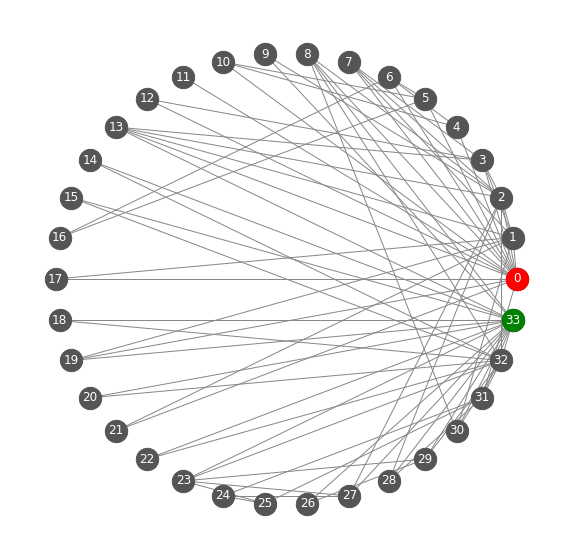

In [3]:
fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')

loc = nx.circular_layout(G)
node_size=500

nx.draw_networkx_nodes(
    G,loc, nodelist=G.nodes(), node_size=node_size, node_color= "#555", edgecolors="#555", ax=ax)
nx.draw_networkx_nodes(
    G,loc, nodelist=[mrhi],node_size=node_size, node_color= "r", edgecolors="r", ax=ax)
nx.draw_networkx_nodes(
    G,loc, nodelist=[officer], node_size=node_size, node_color= "g", edgecolors="g", ax=ax)
nx.draw_networkx_labels(
    G,loc, font_color="#fff")
nx.draw_networkx_edges(G,loc, edge_color="#888");

## Layout spring

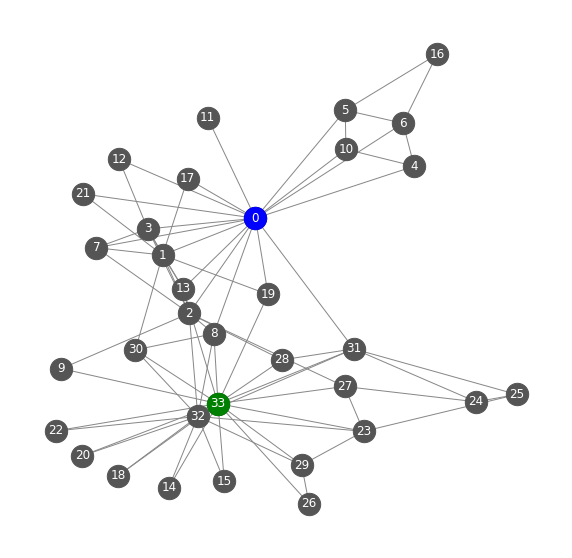

In [4]:
fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')

loc = nx.spring_layout(G, seed=42)
node_size=500

nx.draw_networkx_nodes(
    G,loc, nodelist=G.nodes(), node_size=node_size, node_color= "#555", edgecolors="#555", ax=ax)
nx.draw_networkx_nodes(
    G,loc, nodelist=[mrhi],node_size=node_size, node_color= "b", edgecolors="b", ax=ax)
nx.draw_networkx_nodes(
    G,loc, nodelist=[officer], node_size=node_size, node_color= "g", edgecolors="g", ax=ax)
nx.draw_networkx_labels(
    G,loc, font_color="#fff")
nx.draw_networkx_edges(G,loc, edge_color="#888");

In verde: gruppo Hi, in nero: gruppo Officer, in rosso edges tra i due gruppi

# 1. Info network

<b>Diameter:</b> the diameter of a connected graph is the maximum length of a shortest path. That is, it is the maximum of the distances between pairs of vertices in the graph. If the graph has weights on its edges, then its weighted diameter measures path length by the sum of the edge weights along a path, while the unweighted diameter measures path length by the number of edges. For disconnected graphs, definitions vary: the diameter may be defined as infinite, or as the largest diameter of a connected component, or it may be undefined.

In [5]:
diameter = nx.diameter(G)
f"diametro del network: {diameter}"

'diametro del network: 5'

[[14, 32, 2, 0, 5, 16],
 [15, 32, 2, 0, 5, 16],
 [16, 5, 0, 2, 32, 14],
 [16, 5, 0, 2, 32, 15],
 [16, 5, 0, 2, 32, 18],
 [16, 5, 0, 2, 32, 20],
 [16, 5, 0, 2, 32, 22],
 [16, 5, 0, 31, 25, 23],
 [16, 5, 0, 8, 33, 26],
 [16, 5, 0, 2, 32, 29],
 [18, 32, 2, 0, 5, 16],
 [20, 32, 2, 0, 5, 16],
 [22, 32, 2, 0, 5, 16],
 [23, 25, 31, 0, 5, 16],
 [26, 33, 8, 0, 5, 16],
 [29, 32, 2, 0, 5, 16]]

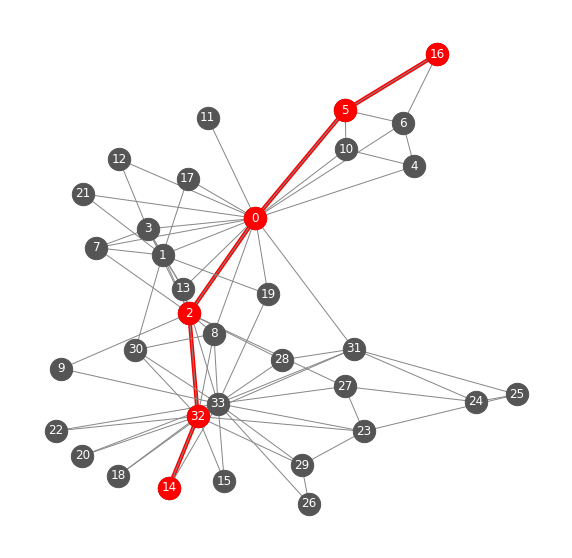

In [6]:
import itertools
lp_nodes = max([nx.shortest_path(G,s,t) for (s,t) in (itertools.permutations(G.nodes(), 2))], key=len)
lp_edges = [(x,lp_nodes[idx+1]) for idx,x in enumerate(lp_nodes[:-1])]

fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')

loc = nx.spring_layout(G, seed=42)
node_size=500

nx.draw_networkx_nodes(
    G,loc, nodelist=G.nodes(), node_size=node_size, node_color= "#555", edgecolors="#555", ax=ax)
nx.draw_networkx_nodes(
    G,loc, nodelist=lp_nodes, node_size=node_size, node_color= "r", edgecolors="r", ax=ax)
nx.draw_networkx_edges(G, loc, edgelist=lp_edges, edge_color="r", width=4, ax=ax)
nx.draw_networkx_labels(
    G,loc, font_color="#fff")
nx.draw_networkx_edges(G,loc,edge_color="#888");

list([nx.shortest_path(G,s,t) for (s,t) in (itertools.permutations(G.nodes(), 2)) 
      if len(nx.shortest_path(G,s,t)) == 6])

<b>Density</b>: 
In a graph of n nodes, the density is the ratio of the number of edges of the graph to the number of edges in a complete graph on n nodes.

In [7]:
density = nx.density(G)
f"density: {density}"

'density: 0.13903743315508021'

<b>Degree distribution</b>

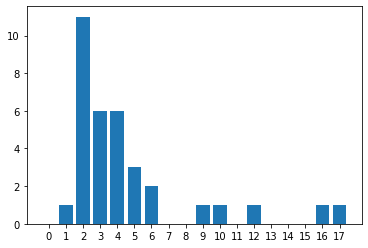

In [74]:
data = nx.degree_histogram(G);
labels, counts = range(0,len(data)), data
plt.bar(labels, counts, align='center')
plt.gca().set_xticks(labels)
plt.show()

<b>Degree centralization</b>

In [9]:
def get_degree_centralization(G):
    n = G.order()
    centrality_values = dict(G.degree()).values()
    c_max = max(centrality_values)
    return sum([ c_max - value for value in centrality_values ]) / ((n-1)*(n-2))

f"centralizzazione: {get_degree_centralization(G)}"

'centralizzazione: 0.3996212121212121'

'centralizzazione: 1.0'

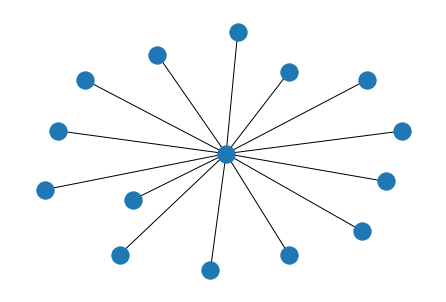

In [10]:
S = nx.Graph()
S.add_nodes_from(range(15))
nx.add_star(S, S.nodes())
loc = nx.spring_layout(S)
nx.draw(S,loc)

f"centralizzazione: {get_degree_centralization(S)}"

'centralizzazione: 0.0'

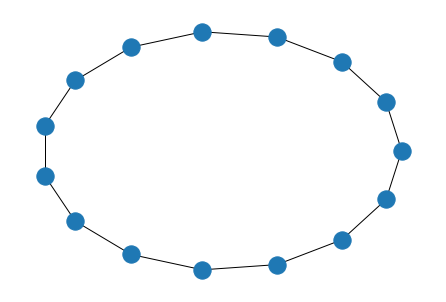

In [11]:
C = nx.Graph()
nodes = range(15)
C.add_nodes_from(nodes)
C.add_edges_from(
    sum([[(x,nodes[idx+1]) for idx,x in enumerate(nodes[:-1])], [(nodes[0], nodes[-1])]], [])
)
loc = nx.circular_layout(C)
nx.draw(C,loc)

f"centralizzazione: {get_degree_centralization(C)}"

# 2. Nodes / edges rilevanti

<b>Degree cenrality</b> the number of links incident upon a node (i.e., the number of ties that a node has)

In [12]:
highest_dc = [ n for n,v in sorted(list(nx.degree(G)), key=lambda e: e[1])[-5:]]
f"nodi con più alta dc: {highest_dc}"

'nodi con più alta dc: [1, 2, 32, 0, 33]'

<b>Bridge</b>:  a bridge, isthmus, cut-edge, or cut arc is an edge of a graph whose deletion increases the graph's number of connected components.

In [13]:
bridges = list(nx.bridges(G))
f"bridges: {bridges}"

'bridges: [(0, 11)]'

In [14]:
# proof
G_clone = G.copy()
cc_before = len(list(nx.connected_components(G_clone)))
display(f"connected components before bridge removal: {cc_before}")
G_clone.remove_edge(*bridges[0])
cc_after = len(list(nx.connected_components(G_clone)))
display(f"connected components before bridge removal: {cc_after}")

'connected components before bridge removal: 1'

'connected components before bridge removal: 2'

# 3. modello previsionale

### Ricerca comunità (Girvan-Newman)

In [66]:
from networkx.algorithms import community
communities_generator = community.girvan_newman(G)
model = sorted(map(sorted, communities_generator))[-1]

e_0 = [0 if G.nodes()[n]['club'] == "Mr. Hi" else 1 for n in model[0]]
e_1 = [0 if G.nodes()[n]['club'] == "Officer" else 1 for n in model[1]]

hit_perc = 1 - sum((e_0 + e_1))/G.order()

f"percentuale di successo: {hit_perc}"

'percentuale di successo: 0.9411764705882353'

In [69]:
focus_nodes = sum([
    [n for n in model[0] if G.nodes()[n]['club'] != "Mr. Hi"],
    [n for n in model[1] if G.nodes()[n]['club'] != "Officer"]
],
[])

f"nodi con errori previsionali: {focus_nodes}"

'nodi con errori previsionali: [2, 8]'

### Ricerca comunità (Clauset-Newman-Moore greedy modularity maximization)

In [95]:
from networkx.algorithms.community import greedy_modularity_communities
(c1, c2, c3) = greedy_modularity_communities(G)

c2_with_c1 = set(sum([list(G.neighbors(n)) for n in c1], [])).intersection(c2)
c2_with_c3 = set(sum([list(G.neighbors(n)) for n in c3], [])).intersection(c2)

display(f"nodi di collegamento c2 e c1 {c2_with_c1}")
display(f"nodi di collegamento c2 e c3 {c2_with_c3}")

'nodi di collegamento c2 e c1 {1, 2, 13, 9}'

'nodi di collegamento c2 e c3 {1, 2, 3, 7, 12, 13, 17, 21}'

In [102]:
comm_officer = list(c1)
comm_mrhi = list(c2) + list(c3)

e_0 = [0 if G.nodes()[n]['club'] == "Mr. Hi" else 1 for n in comm_mrhi]
e_1 = [0 if G.nodes()[n]['club'] == "Officer" else 1 for n in comm_officer]

hit_perc = 1 - sum((e_0 + e_1))/G.order()

f"percentuale di successo: {hit_perc}"

display(c1, c2, c3)

frozenset({8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33})

frozenset({1, 2, 3, 7, 9, 12, 13, 17, 21})

frozenset({0, 4, 5, 6, 10, 11, 16, 19})

## Scisma

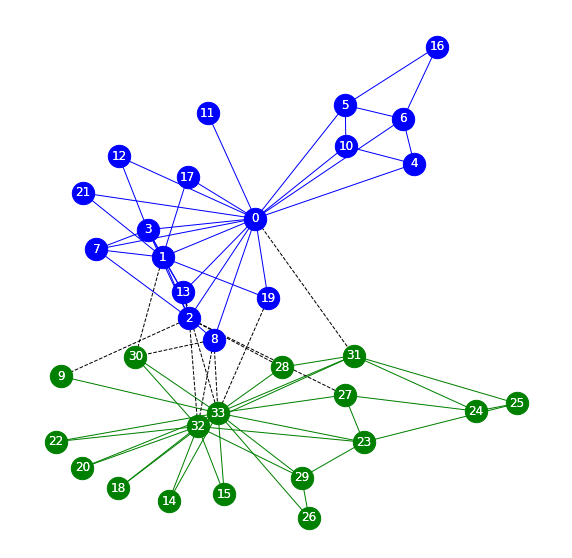

In [103]:
loc = nx.spring_layout(G, seed=42)
node_size=500

fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')

for color, club in [("b","Mr. Hi" ), ("g", 'Officer')]:
    nodes = [ n for n,d in G.nodes(data=True) if d["club"] == club ]
    edges = [ e for e in G.edges() if e[0] in nodes and e[1] in nodes ]
    nx.draw_networkx_nodes(
        G, loc, nodelist=nodes, node_color=color, edgecolors=color, node_size=node_size, ax=ax)
    nx.draw_networkx_edges(G, loc, edgelist=edges, edge_color=color, ax=ax)
    nx.draw_networkx_labels(G, loc, font_color="#fff", ax=ax);

connection_edges = [e for e in G.edges() if G.nodes()[e[0]]['club'] !=  G.nodes()[e[1]]['club']]
nx.draw_networkx_edges(G, loc, edgelist=connection_edges, edge_color="k", style="--", ax=ax);